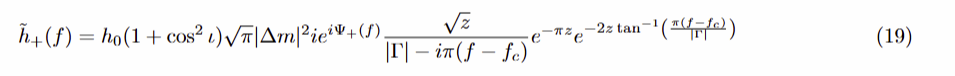

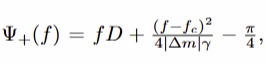

In [25]:
Pkg.resolve()

    Updating `~/GW_free_params.jl/Project.toml`
  [37e2e46d] ↑ LinearAlgebra v1.11.0 ⇒ v1.12.0
    Updating `~/GW_free_params.jl/Manifest.toml`
⌃ [c8ffd9c3] ~ MbedTLS_jll v2.28.6+0 ⇒ v2.28.6+0
  [f43a241f] ↑ Downloads v1.6.0 ⇒ v1.7.0
  [ac6e5ff7] + JuliaSyntaxHighlighting v1.12.0
  [37e2e46d] ↑ LinearAlgebra v1.11.0 ⇒ v1.12.0
  [ca575930] ↑ NetworkOptions v1.2.0 ⇒ v1.3.0
  [44cfe95a] ↑ Pkg v1.11.0 ⇒ v1.12.1
  [2f01184e] ↑ SparseArrays v1.11.0 ⇒ v1.12.0
  [e66e0078] ↑ CompilerSupportLibraries_jll v1.1.1+0 ⇒ v1.3.0+1
  [deac9b47] ↑ LibCURL_jll v8.6.0+0 ⇒ v8.15.0+0
  [e37daf67] ↑ LibGit2_jll v1.7.2+0 ⇒ v1.9.0+0
  [29816b5a] ↑ LibSSH2_jll v1.11.0+1 ⇒ v1.11.3+1
  [14a3606d] ↑ MozillaCACerts_jll v2023.12.12 ⇒ v2025.11.4
  [4536629a] ↑ OpenBLAS_jll v0.3.27+1 ⇒ v0.3.29+0
  [05823500] ↑ OpenLibm_jll v0.8.5+0 ⇒ v0.8.7+0
  [458c3c95] ↑ OpenSSL_jll v3.5.2+0 ⇒ v3.5.4+0
  [efcefdf7] ↑ PCRE2_jll v10.42.0+1 ⇒ v10.44.0+1
  [bea87d4a] ↑ SuiteSparse_jll v7.7.0+0 ⇒ v7.8.3+2
  [83775a58] ↑ Zlib_jll v1.2.13

In [26]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/GW_free_params.jl`
Precompiling packages...
   1693.2 ms  ✓ MbedTLS_jll
   2618.0 ms  ✓ MPItrampoline_jll
   2565.7 ms  ✓ OpenMPI_jll
   2790.6 ms  ✓ FFMPEG_jll
   2998.6 ms  ✓ MPICH_jll
   2880.6 ms  ✓ Qt6Base_jll
   2257.0 ms  ✓ MbedTLS
   4335.8 ms  ✓ OpenSSL
   1227.4 ms  ✓ FFMPEG
   1441.9 ms  ✓ Qt6ShaderTools_jll
   1851.9 ms  ✓ GR_jll
   3152.5 ms  ✓ HDF5_jll
   3782.9 ms  ✓ Qt6Declarative_jll
   1229.0 ms  ✓ Qt6Wayland_jll
  12379.1 ms  ✓ HDF5
  26041.8 ms  ✓ HTTP
   6751.8 ms  ✓ GR
  78134.6 ms  ✓ Plots
  10305.2 ms  ✓ GW
  19 dependencies successfully precompiled in 126 seconds. 286 already precompiled.


In [27]:
using GW

In [31]:
using ForwardDiff

In [32]:
FpFc(det, theta, phi) = _patternFunction(PhenomD(), det, 0.0, theta, phi, 0.0)
FpFc_der(det, theta, phi) = ForwardDiff.jacobian(x -> _patternFunction(PhenomD(), det, 0.0,  x[1], x[2], 0.), [theta, phi])

FpFc(ETLS, 0.,0.).^2, FpFc_der(ETLS, 0.,0.).^2

([0.04398409876390326, 0.37808598882874034], [0.015470717556010915 1.5123439553149614; 0.5624591948513455 0.17593639505561298])

In [33]:
# ETLS
thetav = range(0, stop=pi, length=20)
phiv = range(0, stop=2pi, length=20)

FpFc_vals = [FpFc(ETLS, theta, phi) for theta in thetav, phi in phiv]
FpFc_der_vals = [FpFc_der(ETLS, theta, phi) for theta in thetav, phi in phiv]

20×20 Matrix{Matrix{Any}}:
 [0.124381 -1.22977; 0.749973 0.419448]         …  [0.124381 -1.22977; 0.749973 0.419448]
 [0.0835934 -1.33487; 0.638537 0.4342]             [0.0835934 -1.33487; 0.638537 0.4342]
 [0.0337468 -1.39527; 0.509684 0.437107]           [0.0337468 -1.39527; 0.509684 0.437107]
 [-0.0197567 -1.40441; 0.366928 0.428092]          [-0.0197567 -1.40441; 0.366928 0.428092]
 [-0.0711194 -1.36132; 0.214163 0.4074]            [-0.0711194 -1.36132; 0.214163 0.4074]
 [-0.114775 -1.27065; 0.0555557 0.375595]       …  [-0.114775 -1.27065; 0.0555557 0.375595]
 [-0.145993 -1.14223; -0.104567 0.333544]          [-0.145993 -1.14223; -0.104567 0.333544]
 [-0.161391 -0.989991; -0.261836 0.282395]         [-0.161391 -0.989991; -0.261836 0.282395]
 [-0.159299 -0.830416; -0.411964 0.223544]         [-0.159299 -0.830416; -0.411964 0.223544]
 [-0.139945 -0.680801; -0.550855 0.158594]         [-0.139945 -0.680801; -0.550855 0.158594]
 [-0.105425 -0.557359; -0.674719 0.0893188]     …  [-0.105

In [34]:
# parameters = GenerateCatalog(100, "BBH")
parameters = ReadCatalog("catalog_BBH_n_100_Madau&Dickinson_td_10.0Myrs.h5")
parameters_mat = zeros(length(parameters), length(parameters[1]))
for ii in 1:length(parameters)
    parameters_mat[ii,:] = parameters[ii]
end

Attributes: ["SFR", "date", "format", "local_rate", "number_events", "population", "seed", "time_delay_in_Myrs", "total_number_sources_yr"]
SFR: Madau&Dickinson
date: Thu 23 Oct 2025 14:21:13
format: GWJulia
local_rate: 17.0
number_events: 100
population: BBH
seed: 9084
time_delay_in_Myrs: 10.0
total_number_sources_yr: 35788
Parameters: ["Lambda1", "Lambda2", "chi1", "chi2", "dL", "eta", "iota", "mc", "phi", "phiCoal", "psi", "tcoal", "theta", "z"]


In [35]:
# Now test your type hierarchy:

# 1. Check if PhenomD() is a CBC type
model = BosonSR_ann()#PhenomD()
println("BosonSR_ann() isa NonCBC: ", model isa NonCBC)


BosonSR_ann() isa NonCBC: true


In [38]:

# 2. Check if PhenomD() is a GrModel type  
println("$(model) isa GrModel: ", model isa GrModel)

# 3. Check if PhenomD() is a Model type
println("$(model) isa Model: ", model isa Model)

# 4. Get the full type hierarchy
println("Type of PhenomD(): ", typeof(model))
println("Supertypes: ", supertypes(typeof(model)))

# 5. Check other models too
tiger_model = PhenomD_TIGER(2.0)
println("$(tiger_model) isa BgrModel: ", tiger_model isa BgrModel)
println("$(tiger_model) isa CBC: ", tiger_model isa CBC)
println("$(tiger_model) isa Model: ", tiger_model isa Model)

# 6. You can also check the abstract type hierarchy directly
println("CBC <: Model: ", CBC <: Model)
println("GrModel <: CBC: ", GrModel <: CBC) 
println("BgrModel <: CBC: ", BgrModel <: CBC)

BosonSR_ann() isa GrModel: false
BosonSR_ann() isa Model: true
Type of PhenomD(): BosonSR_ann
Supertypes: (BosonSR_ann, NonCBC, Model, Any)
PhenomD_TIGER(2.0, "BBH") isa BgrModel: true
PhenomD_TIGER(2.0, "BBH") isa CBC: true
PhenomD_TIGER(2.0, "BBH") isa Model: true
CBC <: Model: true
GrModel <: CBC: true
BgrModel <: CBC: true


In [12]:
M_ann_ = 3.1e-04  # in solar masses
mua_ann = 2e-16  # in GeV
sigma_M = 0.1 * M_ann_
sigma_mua = 0.1 * mua_ann
samples_M = randn(100) .* sigma_M .+ M_ann_
samples_mua = randn(100) .* sigma_mua .+ mua_ann
intrinsic_parameters = (samples_M, samples_mua, zeros(100))

intrinsic_parameters_mat = zeros(length(intrinsic_parameters), length(intrinsic_parameters[1]))
for ii in 1:length(intrinsic_parameters)
    intrinsic_parameters_mat[ii,:] = intrinsic_parameters[ii]
end


In [13]:
intrinsic_parameters isa Tuple

true

In [14]:
SNR_scalar = SNR(BosonSR(), [ETLS, ETMR], Tuple(intrinsic_parameters_mat[:,1]), parameters_mat[5:10,1]...)
SNR_vector = SNR(BosonSR(), [ETLS, ETMR], intrinsic_parameters, parameters[5:10]...)

UndefVarError: UndefVarError: `SNR` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [15]:
Strain(PhenomD(),
    ETLS,
    1:1:10, 10.0, 0.25, 0.5, 0.5, 1.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6)

UndefVarError: UndefVarError: `Strain` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [16]:
Strain(BosonSR(),
    ETLS,
    1:1:10, Tuple([10.0, 0.25, 0.5]), 1.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6)

UndefVarError: UndefVarError: `Strain` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [17]:
FIM_scalar = FisherMatrix(BosonSR(), [ETLS, ETMR], Tuple(intrinsic_parameters_mat[:,1]), parameters_mat[5:11,1]...)
# SNR_vector = SNR(BosonSR(), [ETLS, ETMR], intrinsic_parameters, parameters[5:10]...)

UndefVarError: UndefVarError: `FisherMatrix` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [18]:
FIM_vector = FisherMatrix(BosonSR(), [ETLS, ETMR], intrinsic_parameters, parameters[5:11]...)

UndefVarError: UndefVarError: `FisherMatrix` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [19]:
size(intrinsic_parameters_mat)

(3, 100)

In [23]:
intrinsic_parameters

([0.00029642142278602895, 0.00033589046589433747, 0.00035206936363257657, 0.00031781118089988745, 0.00033260197144599355, 0.0003104381675872397, 0.00033901811041242737, 0.00031891483550132796, 0.0002794668360865247, 0.0003046327236934464  …  0.0002941698003143714, 0.0002918577565170953, 0.00036443666560867944, 0.00032536429338844827, 0.0002707459359775877, 0.0003780109656474934, 0.00032148803670417527, 0.00025492324314917115, 0.0002660230228134021, 0.0002997993864017205], [1.7335546822698852e-16, 2.1513542704528415e-16, 2.438027817541341e-16, 2.1147512268752765e-16, 1.9516493244864846e-16, 1.8869576223263846e-16, 2.0014590777553263e-16, 1.924306650886654e-16, 2.264295367055121e-16, 1.7742728482117948e-16  …  2.392331683399965e-16, 1.972672507610325e-16, 2.1857567896899497e-16, 1.9180967668881775e-16, 1.939682396358146e-16, 1.9774046695066443e-16, 1.9241594498450462e-16, 1.9079647668546493e-16, 1.9070580784879733e-16, 1.9524658659280586e-16], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [24]:
FisherMatrix(BosonSR(), ETLS, intrinsic_parameters, parameters[5:11]...)

UndefVarError: UndefVarError: `FisherMatrix` not defined in `Main`
Suggestion: check for spelling errors or missing imports.